## EDA Project

### Mental Health Data

### Dataset Overview
      This dataset studies how social media use affects the mental health of teenagers. It includes daily habits like social media hours, sleep,
      stress, anxiety, and physical activity.The goal is to understand if high social media use is linked with problems like stress, anxiety, 
      and depression.

### Import Modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Data

In [2]:
df = pd.read_csv('Mental Health Care.csv')

In [3]:
df

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14.0,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19.0,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17.0,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15.0,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15.0,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18.0,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16.0,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14.0,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15.0,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [4]:
df.shape

(1200, 13)

### Data Info
To look up the basic dataframe stats and missing values

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   float64
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1187 non-null   float64
 3   platform_usage            1189 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1179 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(6), int64(4), str(3)
memory usage: 122.0 KB


### Check Dupicates Values

In [6]:
df[df.duplicated(keep=False)]

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label


### Missing Values Check

In [8]:
df.isnull().sum()


age                          0
gender                       0
daily_social_media_hours    13
platform_usage              11
sleep_hours                  0
screen_time_before_sleep     0
academic_performance        21
physical_activity            0
social_interaction_level     0
stress_level                 0
anxiety_level                0
addiction_level              0
depression_label             0
dtype: int64

###  Pre-processing of Data

In [7]:
df['age'] = df['age'].astype('int')

In [8]:
df['age']

0       14
1       19
2       17
3       15
4       15
        ..
1195    18
1196    16
1197    14
1198    15
1199    16
Name: age, Length: 1200, dtype: int64

###  Handling Missing Values 

In [9]:
df['platform_usage'].isnull().sum()

np.int64(11)

In [10]:
df['platform_usage'] = df['platform_usage'].ffill().copy()

In [11]:
df['daily_social_media_hours'].isnull().sum()

np.int64(13)

In [1]:
df.fillna({'daily_social_media_hours':df['daily_social_media_hours'].mean()},inplace = True)

In [13]:
df['academic_performance'].isnull().sum()

np.int64(21)

In [2]:
df.fillna({'academic_performance':df['academic_performance'].mean()},inplace = True)

### Column Data Type Assignment

In [15]:
Numeric_Column = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance','physical_activity']
Categorical_Column = ['platform_usage', 'social_interaction_level', 'stress_level','anxiety_level','addiction_level']
Traget_Column = ['depression_label']

In [16]:
df[Numeric_Column].describe() #Statistical Analysis only on numeric columns

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.530160,6.449417,1.740333,2.988490,1.014500
std,2.021947,2.019488,1.442677,0.716660,0.572135,0.582185
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.507500,0.500000
50%,16.000000,4.500000,6.500000,1.800000,2.988490,1.000000
75%,18.000000,6.300000,7.600000,2.400000,3.470000,1.500000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000


### Exploring Data & Visualization

<Axes: >

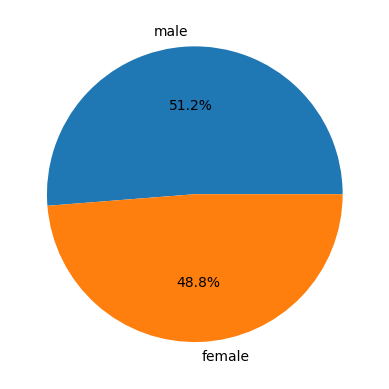

In [17]:
# Percentage of Gender in Data
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')

#### Observation: The percentage of Male gender is more than the Female gender in the data.

In [18]:
# Total Sleep_hours on basis of gender
sleep_hours = df.groupby('gender')['sleep_hours'].sum().astype('int')
print(sleep_hours)

gender
female    3800
male      3938
Name: sleep_hours, dtype: int64


Text(0.5, 1.0, 'Total Sleep hours by Gender')

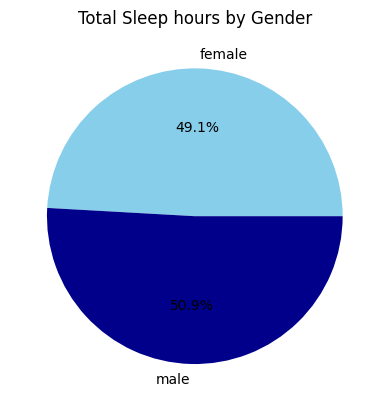

In [19]:
# Total Sleep_hours on basis of gender
plt.pie(sleep_hours,labels=sleep_hours.index,autopct='%1.1f%%',colors = ['skyblue', 'darkblue'])
plt.title('Total Sleep hours by Gender')

#### Observation: There is a slight difference between the Total Sleep hours of Male and Female gender.

In [20]:
# Total Daily hours of platforms
daily_hours = df.groupby('platform_usage')['daily_social_media_hours'].sum().astype('int')
total_hours = pd.DataFrame(daily_hours.sort_values(ascending = False))
total_hours

,daily_social_media_hours
platform_usage,
Instagram,1873
TikTok,1813
Both,1749


Text(0, 0.5, 'Daily Social Media Hours')

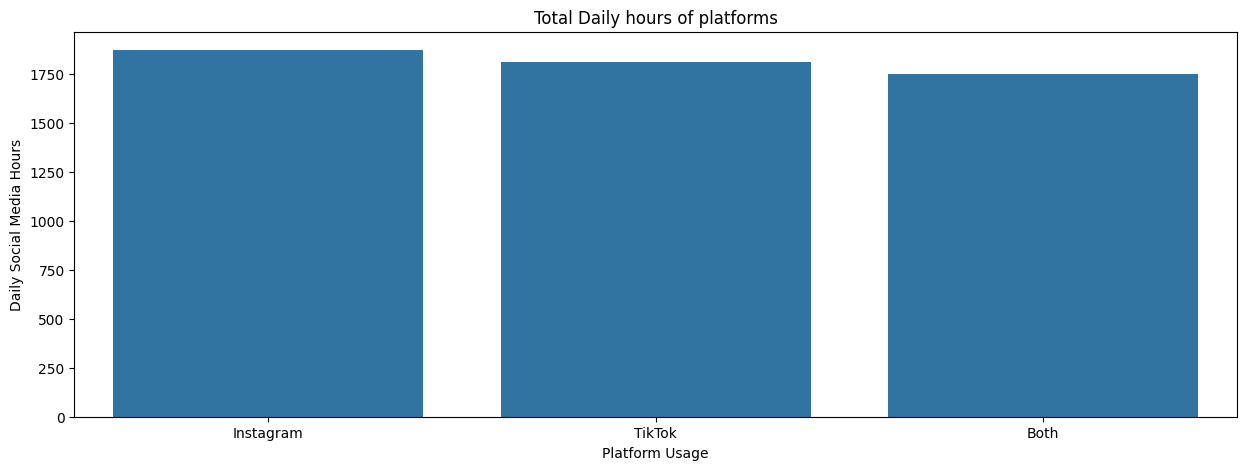

In [21]:
plt.figure(figsize = (15,5))
sns.barplot(x = 'platform_usage' , y = 'daily_social_media_hours', data=total_hours)
plt.title('Total Daily hours of platforms')
plt.xlabel("Platform Usage")
plt.ylabel('Daily Social Media Hours')

#### Observation: The teenagers likes to spend most of their daily hours in instagram as compare to TikTok.

Text(0.5, 1.0, 'Count_Plot for platform_usage')

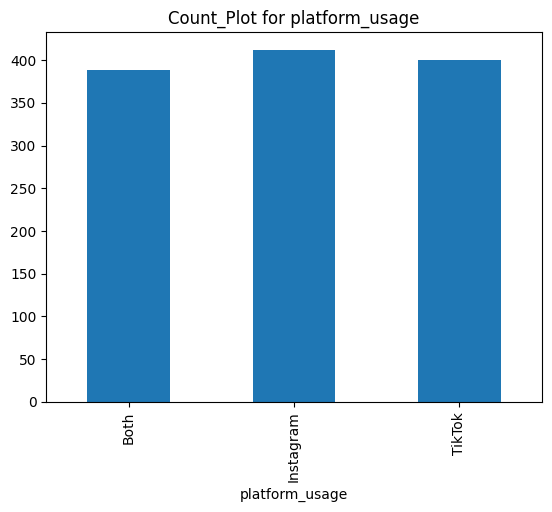

In [22]:
df['platform_usage'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Count_Plot for platform_usage')

#### Observation: The Paltform Instagram has the higher value in the data from TikTok.

Text(0.5, 1.0, 'Total Values of Depression level')

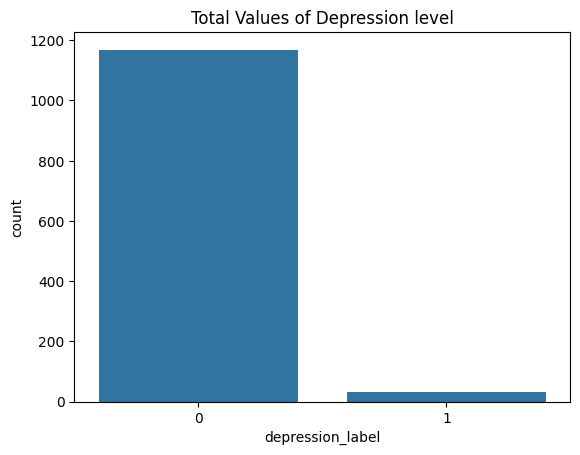

In [24]:
sns.countplot(data=df,x=df[Traget_Column[0]])
plt.title('Total Values of Depression level')

#### observation:The dataset is highly imbalanced class 0(almost 1150) has significantly more samples than class 1(almost 50)which has very few entries.

Text(0.5, 1.0, 'Age Distribution by Gender')

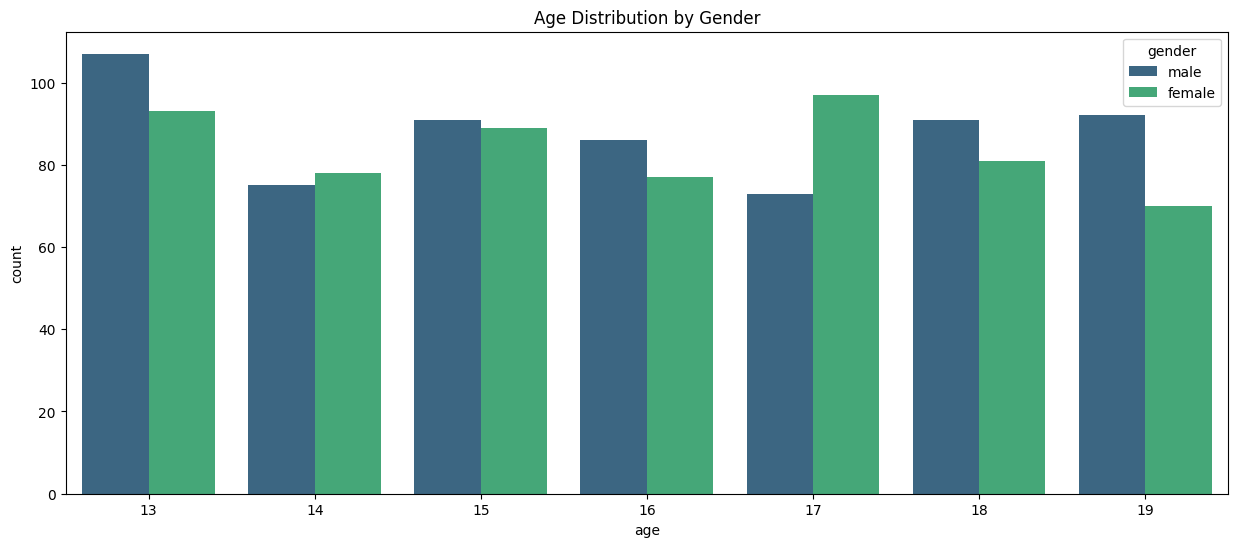

In [25]:
# Distribution of ages
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x='age', hue='gender', palette='viridis')
plt.title('Age Distribution by Gender')

#### Observation: The dataset shows slightly variations in age distribution between genders, with no extreme differences across most age groups.

In [26]:
# total sleep hours of ages
age = df.groupby('age')['sleep_hours'].sum().astype('int')
total_sleep = pd.DataFrame(age.sort_values(ascending = False))
total_sleep

,sleep_hours
age,
13,1297
15,1168
17,1106
18,1093
16,1057
19,1049
14,966


Text(0, 0.5, 'Sleep Hours')

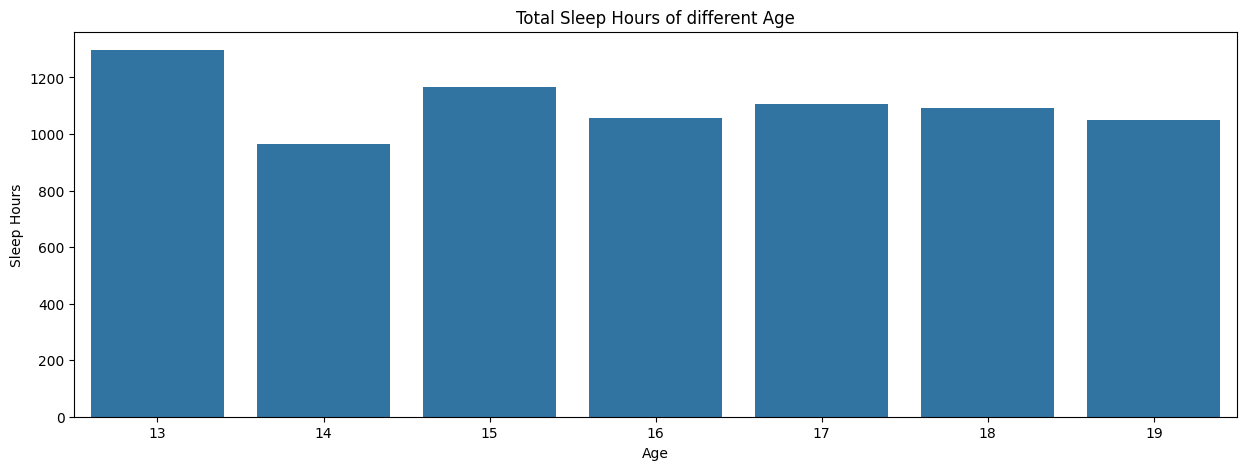

In [27]:
plt.figure(figsize = (15,5))
sns.barplot(x = 'age' , y= 'sleep_hours' , data = total_sleep)
plt.title('Total Sleep Hours of different Age')
plt.xlabel('Age')
plt.ylabel('Sleep Hours')

#### Observation: The age 14 years has the lowest total daily sleep hours, below 1000 hours. 

In [28]:
#Total values of Stress level
df['social_interaction_level'].value_counts()

social_interaction_level
medium    416
low       415
high      369
Name: count, dtype: int64

Text(0.5, 1.0, 'Count_Plot of Social Interaction Level')

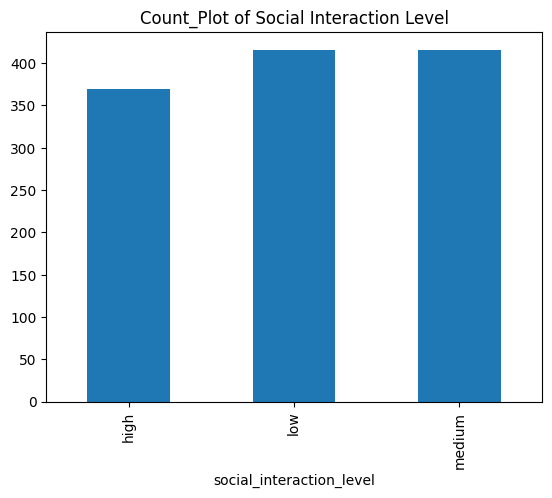

In [29]:
df['social_interaction_level'].value_counts().sort_index().plot(kind = 'bar')
plt.title('Count_Plot of Social Interaction Level')

#### Observation: The data suggests that the majority of individuals fall into the medium to low social interaction range.

In [30]:
pd.crosstab(df['stress_level'] , df['depression_label'])

depression_label,0,1
stress_level,,
1,134,0
2,108,0
3,116,0
4,139,0
5,129,0
6,114,0
7,97,9
8,97,7
9,116,6


Text(0.5, 1.0, 'Depression Label in Stress Level')

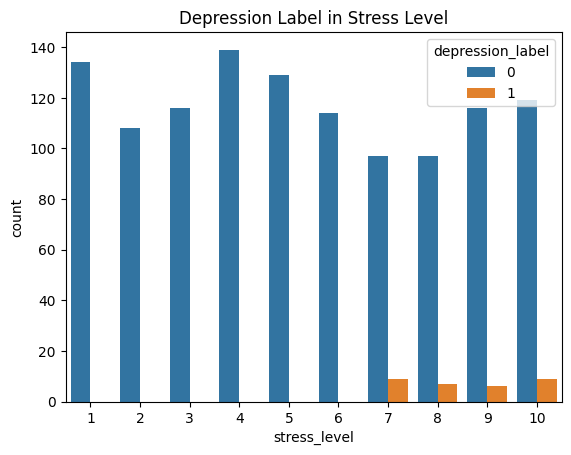

In [31]:
sns.countplot(x='stress_level', hue='depression_label', data=df)
plt.title('Depression Label in Stress Level')

#### Observation: The depression cases start appearing more noticeable at higher stress levels(7-10).

In [32]:
pd.crosstab(df['gender'] , df['depression_label'])

depression_label,0,1
gender,,
female,568,17
male,601,14


Text(0.5, 1.0, 'Depression level in gender')

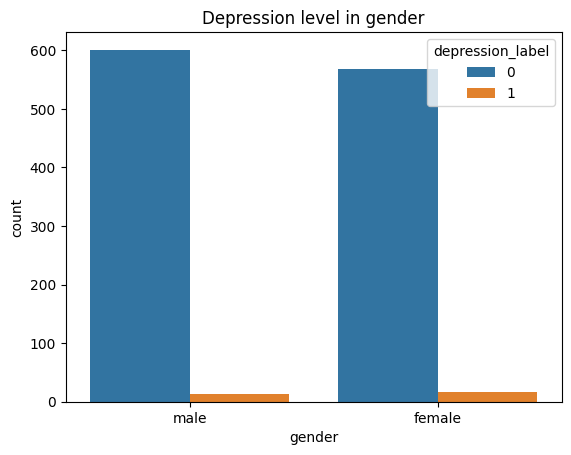

In [33]:
sns.countplot(x='gender', hue='depression_label', data=df)
plt.title('Depression level in gender')

#### Observation: The graph is highly imbalanced because non-depressed cases are much larger than depressed cases.

Text(0.5, 1.0, 'Correlation Analysis')

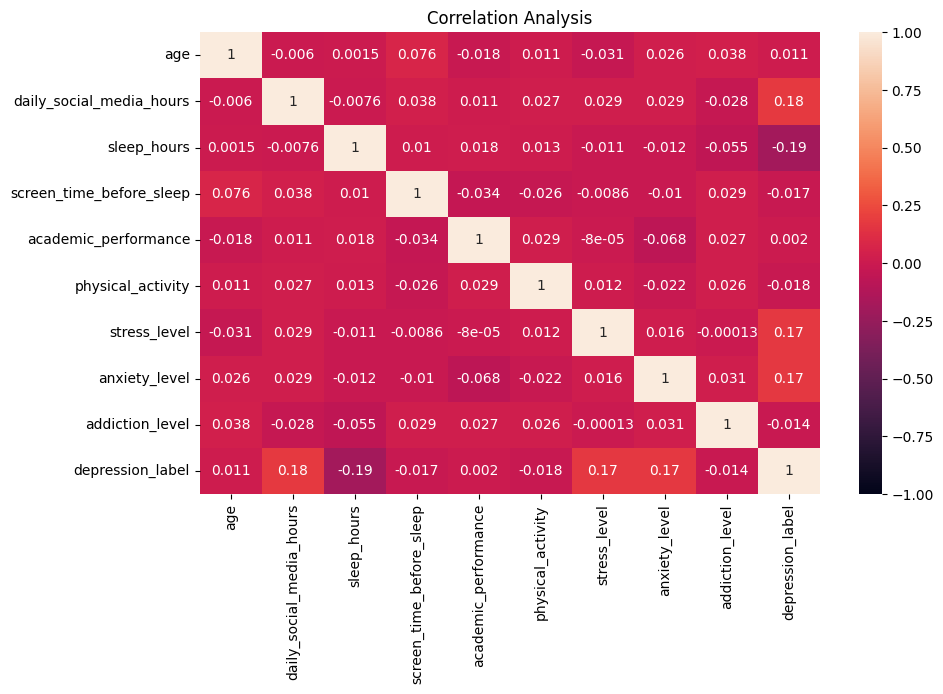

In [7]:
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(np.number)
sns.heatmap(numeric_df.corr(),annot = True, vmin=-1, vmax=1)
plt.title('Correlation Analysis')

#### Observation:
  -  Weak Overall Correlations: Most of the values in this dataset are very close to zero (e.g., 0.0015, -0.014). This suggests that, in this specific dataset, these factors do not have strong linear relationships with one another.
  -  Depression level has a slight positive correlation with daily social media hours (0.18), stress level (0.17), and anxiety level (0.17), indicating these factors may slightly increase depression risk.
  -  Sleep Hours vs. Addiction Level (-0.055): Weak negative relationship. It suggests that as addiction levels (likely social media/internet) increase, hours of sleep tend to decrease slightly.     

### Key Insights:
  -  Higher social media usage (especially before sleep) is associated with lower sleep duration and higher stress/anxiety.
  -  The teenagers using multiple social media paltforms like instagram, tiktok which leads to higher addiction level and depression scores in them.
  -  Stress and anxiety level has a negative correlation with academic performance, as increase in stress and anxiety leads to decrease in academic performance.
  -  The depressed teens has higher stress, anxiety, screen time, less sleep, addiction level as compared to non-depressed teens.